1. Create a straight line dataset using the linear regression formula (weight * X + bias)

* Set weight=0.3 and bias=0.9 there should be at least 100 datapoints total.

* Split the data into 80% training, 20% testing.

* Plot the training and testing data so it becomes visual.

In [59]:
#import libraries
import torch
from torch import nn # nn contains all of PyTorch's building blocks for neural networks
import matplotlib.pyplot as plt

# Check PyTorch version
torch.__version__

'2.1.0+cpu'

In [60]:
# Create *known* parameters
weight = 0.3
bias = 0.9

# Create  100 data points: X - generate randomly, Y - calculate

X = torch.linspace(0, 1, 100).unsqueeze(dim=1)
y = weight * X + bias

#Check last 10 data points
X[:10], y[:10]

(tensor([[0.0000],
         [0.0101],
         [0.0202],
         [0.0303],
         [0.0404],
         [0.0505],
         [0.0606],
         [0.0707],
         [0.0808],
         [0.0909]]),
 tensor([[0.9000],
         [0.9030],
         [0.9061],
         [0.9091],
         [0.9121],
         [0.9152],
         [0.9182],
         [0.9212],
         [0.9242],
         [0.9273]]))

In [61]:
# Create train/test split
train_split = int(0.8 * len(X)) # 80% of data used for training set, 20% for testing
X_train, y_train = X[:train_split], y[:train_split] # let us fill with data training set
X_test, y_test = X[train_split:], y[train_split:] # let us fill with data test set

# we have 80 data points in train and 20 data points in test, because in total we have generated 100 data points
len(X_train), len(y_train), len(X_test), len(y_test)

(80, 80, 20, 20)

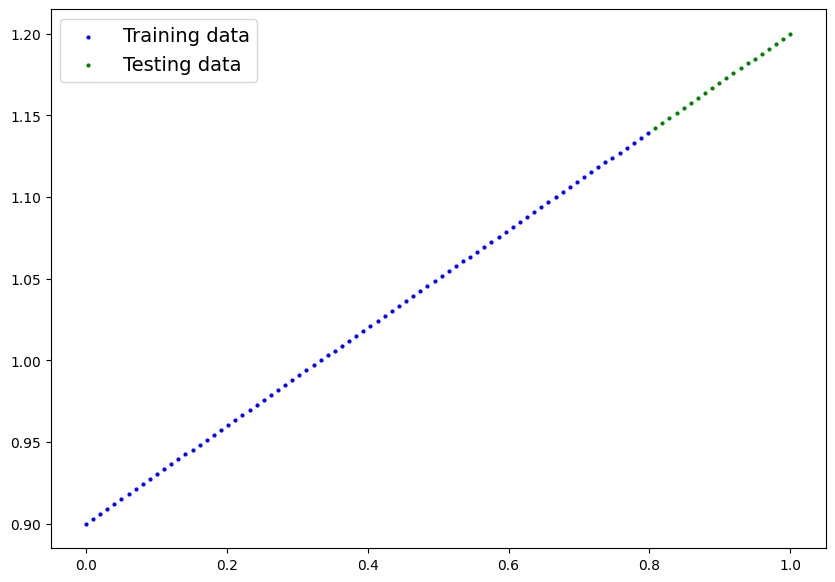

In [62]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
        plt.figure(figsize=(10, 7))

        # Plot training data in blue
        plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

        # Plot test data in green
        plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

        if predictions is not None:
        # Plot the predictions in red (predictions were made on the test data), that will not be plotted, since we did not predict yet
            plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

        # Show the legend
        plt.legend(prop={"size": 14})

plot_predictions()
# as a result blue set belongs to training and green belongs to testing

2. Build a PyTorch model by subclassing nn.Module.
* Inside should be a randomly initialized nn.Parameter() with requires_grad=True, one for weights and one for bias.

* Implement the forward() method to compute the linear regression function you used to create the dataset in 1.

* Once you've constructed the model, make an instance of it and check its state_dict().

Note: If you'd like to use nn.Linear() instead of nn.Parameter() you can.

In [63]:
# Create a Linear Regression model class
class LinearRegressionModel(nn.Module): # <- almost everything in PyTorch is a nn.Module (think of this as neural network lego blocks)
    def __init__(self):
        super().__init__() 
        self.weights = nn.Parameter(torch.randn(1, # <- start with random weights (this will get adjusted as the model learns)
                                                dtype=torch.float), # <- PyTorch loves float32 by default
                                   requires_grad=True) # <- can we update this value with gradient descent?)

        self.bias = nn.Parameter(torch.randn(1, # <- start with random bias (this will get adjusted as the model learns)
                                            dtype=torch.float), # <- PyTorch loves float32 by default
                                requires_grad=True) # <- can we update this value with gradient descent?))

    # Forward defines the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" is the input data (e.g. training/testing features)
        return self.weights * x + self.bias # <- this is the linear regression formula (y = m*x + b)

In [64]:
# Set manual seed since nn.Parameter are randomly initialzied
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = LinearRegressionModel()

# Check the nn.Parameter(s) within the nn.Module subclass we created
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [65]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [66]:
#making predictions torch.inference_mode()

with torch.inference_mode():
  y_preds = model_0(X_test)
#y_preds

3. Create a loss function and optimizer using nn.L1Loss() and torch.optim.SGD(params, lr) respectively.

* Set the learning rate of the optimizer to be 0.01 and the parameters to optimize should be the model parameters from the model you created in 2.

* Write a training loop to perform the appropriate training steps for 300 epochs.
* The training loop should test the model on the test dataset every 20 epochs.

In [67]:
loss_fn = nn.L1Loss()

optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr = 0.01) # learning rate is hyperparameter

In [76]:
torch.manual_seed(42)

#training
epochs = 300
#tracking of parameters
epoch_count = [] # how much loops, hyperparameter
test_loss_values = [] # test set loss
train_loss_values = [] # train set loss

# training loop
for epoch in range (epochs):
  model_0.train()
  #forward pass
  y_pred = model_0(X_train)
  #loss
  loss = loss_fn(y_pred, y_train)
  #optimizer
  optimizer.zero_grad()
  #perform back prop on the loss w respect to the params of the model
  loss.backward()
  #gradient descent
  optimizer.step()
  if epoch % 20 == 0:
    epoch_count.append(epoch)
    train_loss_values.append(loss.detach().numpy())
    print(f"Epoch {epoch}/{epochs}, Training Loss: {loss.item()}")
    model_0.eval() #turns off different settings not needed for evaluation/testing
    with torch.inference_mode():
      test_pred = model_0(X_test)
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type
      test_loss_values.append(test_loss.detach().numpy())
      print(epochs, loss, test_loss)


Epoch 0/300, Training Loss: 0.004876463208347559
300 tensor(0.0049, grad_fn=<MeanBackward0>) tensor(0.0061)
Epoch 20/300, Training Loss: 0.004876463208347559
300 tensor(0.0049, grad_fn=<MeanBackward0>) tensor(0.0061)
Epoch 40/300, Training Loss: 0.004876463208347559
300 tensor(0.0049, grad_fn=<MeanBackward0>) tensor(0.0061)
Epoch 60/300, Training Loss: 0.004876463208347559
300 tensor(0.0049, grad_fn=<MeanBackward0>) tensor(0.0061)
Epoch 80/300, Training Loss: 0.004876463208347559
300 tensor(0.0049, grad_fn=<MeanBackward0>) tensor(0.0061)
Epoch 100/300, Training Loss: 0.004876463208347559
300 tensor(0.0049, grad_fn=<MeanBackward0>) tensor(0.0061)
Epoch 120/300, Training Loss: 0.004876463208347559
300 tensor(0.0049, grad_fn=<MeanBackward0>) tensor(0.0061)
Epoch 140/300, Training Loss: 0.004876463208347559
300 tensor(0.0049, grad_fn=<MeanBackward0>) tensor(0.0061)
Epoch 160/300, Training Loss: 0.004876463208347559
300 tensor(0.0049, grad_fn=<MeanBackward0>) tensor(0.0061)
Epoch 180/300, T

4. Make predictions with the trained model on the test data.
* Visualize these predictions against the original training and testing data 

In [70]:
with torch.inference_mode():
    y_preds_new = model_0(X_test)

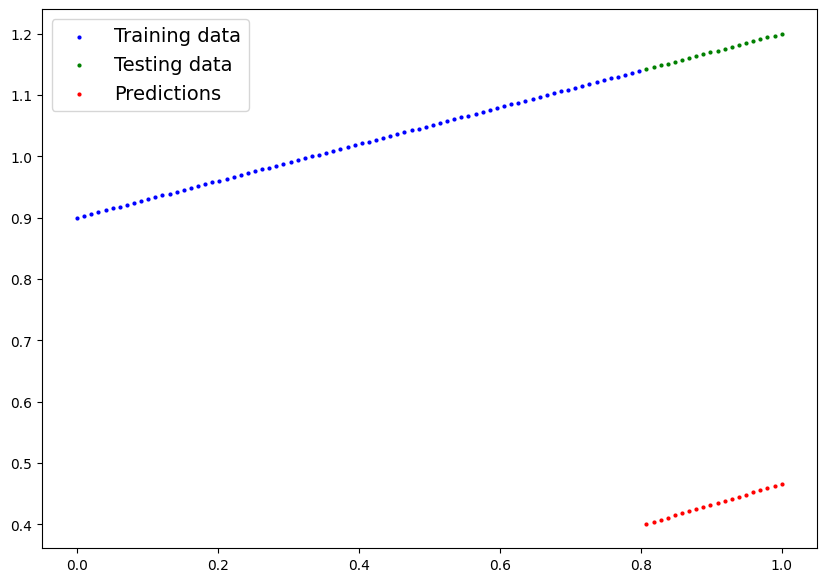

In [71]:
plot_predictions(predictions = y_preds)

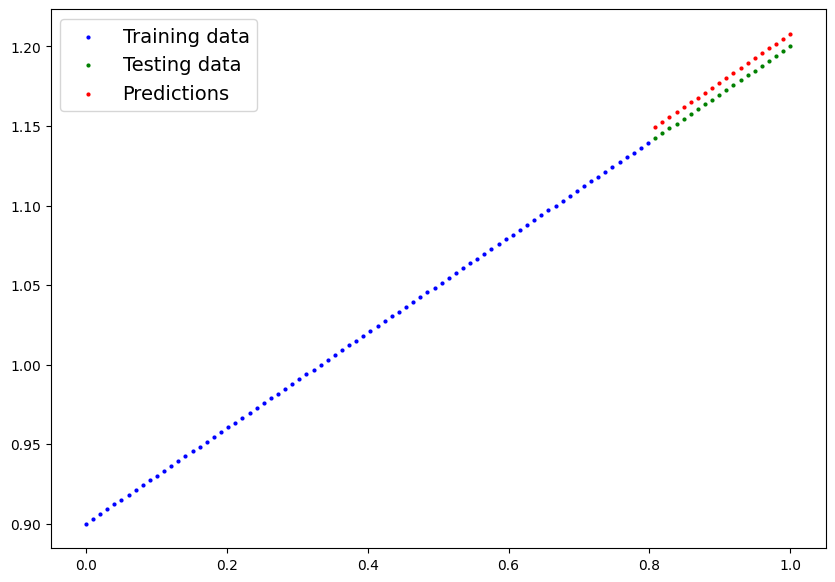

In [72]:
plot_predictions(predictions=y_preds_new)

In [73]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3052])), ('bias', tensor([0.9028]))])

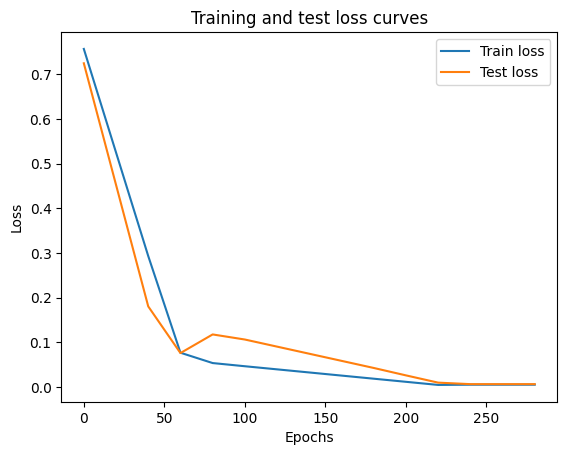

In [74]:
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

5. Save your trained model's state_dict() to file.
* Create a new instance of your model class you made in 2. and load in the state_dict() you just saved to it.
* Perform predictions on your test data with the loaded model and confirm they match the original model predictions from 4.

In [75]:
from pathlib import Path

# 1. Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
MODEL_NAME = "01_home_task_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(), # only saving the state_dict() only saves the models learned parameters
           f=MODEL_SAVE_PATH)

Saving model to: models\01_home_task_0.pth
